## Surface climate, radiative and temperature ersponces to the experiments

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import calendar
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.path as mpath
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
import imageio
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime #import datetime
from glob import glob
from scipy import signal

In [ ]:
# dask
import dask
import dask.array as da
import distributed
from dask.distributed import Client

client = Client()
client

/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41723 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:41723/status,
Dashboard: http://127.0.0.1:41723/status,Workers: 8
Total threads: 32,Total memory: 35.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:41915,Workers: 0
Dashboard: http://127.0.0.1:41723/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:40035,Total threads: 4
Dashboard: http://127.0.0.1:40949/status,Memory: 4.38 GiB
Nanny: tcp://127.0.0.1:37807,


2026-02-18 15:00:26,642 - distributed.nanny - WARNING - Restarting worker
2026-02-18 15:31:28,198 - distributed.nanny - WARNING - Restarting worker


In [3]:
path_atm = "/nird/datapeak/NS1004K/elihho/NHIST_tropochem_250916/atm/hist"
ds_19 = xr.open_mfdataset(f"{path_atm}/NHIST_tropstratchem_f09_tn14_20250917_1975_2014.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7f3b41e2f100>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [4]:
path_atm_22 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251125_pinatubo10Tg22_e01/atm/hist"
ds_22 = xr.open_mfdataset(f"{path_atm_22}/NHIST_tropstratchem_f09_tn14_20251125_Pinatubo10Tg22_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7f3b41e2f100>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [6]:
path_atm_19_c =  "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260116_pinatubo10tg_19_c/atm/hist"
ds_19_c = xr.open_mfdataset(f"{path_atm_19_c}/NHIST_tropstratchem_f09_tn14_20260116_Pinatubo10Tg19_02.cam.h0.*.nc", combine="by_coords", parallel=True)

In [7]:
path_atm_24 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251129_pinatubo17Tg24_e01/atm/hist"
ds_24 = xr.open_mfdataset(f"{path_atm_24}/NHIST_tropstratchem_f09_tn14_20251129_Pinatubo17Tg24_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7f3b41e2f100>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [9]:
path_atm_1825 = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251204_pinatubo10Tg18_25_e01/atm/hist"
ds_1825 = xr.open_mfdataset(f"{path_atm_1825}/NHIST_tropstratchem_f09_tn14_20251204_Pinatubo10Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7f3b41e2f100>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [10]:
path_atm_1825_17tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251207_pinatubo17Tg18_25_e01/atm/hist"
ds_1825_17tg = xr.open_mfdataset(f"{path_atm_1825_17tg}/NHIST_tropstratchem_f09_tn14_20251207_Pinatubo17Tg18_25_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7f3b41e2f100>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [11]:
path_atm_1tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251210_pinatubo1Tg19_e01/atm/hist"
ds_1tg = xr.open_mfdataset(f"{path_atm_1tg}/NHIST_tropstratchem_f09_tn14_20251210_Pinatubo1Tg19_01.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7f3b41e2f100>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [12]:
path_atm_1pr = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20251223_pinatubo10Tg_1pr/atm/hist"
ds_1pr = xr.open_mfdataset(f"{path_atm_1pr}/NHIST_tropstratchem_f09_tn14_20251223_Pinatubo10Tg19_1pr.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7f3b41e2f100>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [14]:
path_atm_60tg = "/nird/datapeak/NS1004K/elihho/NHIST_tropstratchem_20260108_pinatubo60Tg19_e01/atm/hist"
ds_60tg = xr.open_mfdataset(f"{path_atm_60tg}/NHIST_tropstratchem_f09_tn14_20260107_Pinatubo60Tg19.cam.h0.*.nc", combine="by_coords", parallel=True)

Exception ignored in: <function CachingFileManager.__del__ at 0x7f3b41e2f100>
Traceback (most recent call last):
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/nird/home/elihho/miniconda3/envs/master/lib/python3.13/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2669, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2636, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2164, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


In [15]:
client.close()

In [16]:
def shift_one_month_back(t):
    if t.month == 1:
        return cftime.DatetimeNoLeap(t.year - 1, 12, t.day, t.hour, t.minute, t.second)
    else:
        return cftime.DatetimeNoLeap(t.year, t.month - 1, t.day, t.hour, t.minute, t.second)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19['time'].values])
ds_19 = ds_19.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_22['time'].values])
ds_22 = ds_22.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_19_c['time'].values])
ds_19_c = ds_19_c.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_24['time'].values])
ds_24 = ds_24.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825['time'].values])
ds_1825 = ds_1825.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1825_17tg['time'].values])
ds_1825_17tg = ds_1825_17tg.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_1tg['time'].values])
ds_1tg = ds_1tg.assign_coords(time=shifted_time)

In [17]:
shifted_time = np.array([shift_one_month_back(t) for t in ds_1pr['time'].values])
ds_1pr = ds_1pr.assign_coords(time=shifted_time)

shifted_time = np.array([shift_one_month_back(t) for t in ds_60tg['time'].values])
ds_60tg = ds_60tg.assign_coords(time=shifted_time)

In [18]:
lat = ds_19["lat"]
weighted_lat = np.cos(np.deg2rad(lat))
lat_22 = ds_22["lat"]
weighted_lat_22 = np.cos(np.deg2rad(lat_22))
lat_19_c = ds_19_c["lat"]
weighted_lat_19_c = np.cos(np.deg2rad(lat_19_c))
lat_24 = ds_24["lat"]
weighted_lat_24 = np.cos(np.deg2rad(lat_24))
lat_1825 = ds_1825["lat"]
weighted_lat_1825 = np.cos(np.deg2rad(lat_1825))
lat_1825_17tg = ds_1825_17tg["lat"]
weighted_lat_1825_17tg = np.cos(np.deg2rad(lat_1825_17tg))
lat_1tg = ds_1tg["lat"]
weighted_lat_1tg = np.cos(np.deg2rad(lat_1tg))
lat_1pr = ds_1pr["lat"]
weighted_lat_1pr = np.cos(np.deg2rad(lat_1pr))
lat_60tg = ds_60tg["lat"]
weighted_lat_60tg = np.cos(np.deg2rad(lat_60tg))

In [19]:
temp_ctrl = ds_19["T"]   # long baseline run
baseline = temp_ctrl.sel(time=slice("1976-01", "1981-12"))
base = baseline.groupby("time.month").mean("time")

In [20]:
def plot_temp_anomaly_lat_time(
    ds,
    base_clim,
    lev=50,
    plot_period=("1991-01-01", "1996-01-01"),
    eruption_time=cftime.DatetimeNoLeap(1991, 6, 15),
    lat_marker=15,
    ax=None,
    cmap="RdYlBu_r",
    title=None,
    add_colorbar=True,
):

    temp = ds["T"]
    temp_anom = temp.groupby("time.month") - base_clim

    temp_sel = temp_anom.sel(time=slice(*plot_period))
    temp_sel = temp_sel.sel(lev=lev, method="nearest")
    temp_lat_time = temp_sel.mean(dim="lon")

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))

    p = temp_lat_time.T.plot(
        ax=ax,
        x="time",
        y="lat",
        cmap=cmap,
        add_colorbar=add_colorbar,
        cbar_kwargs={"label": "Temperature anomaly (K)"} if add_colorbar else None,
    )

    if eruption_time is not None:
        ax.plot(
            eruption_time,
            lat_marker,
            marker="^",
            color="red",
            markersize=9,
            zorder=5,
        )

    ax.set_xlabel("Time")
    ax.set_ylabel("Latitude")

    if title:
        ax.set_title(title)

    return ax



<Axes: title={'center': 'Temperatur anomaly at ~50hPa, all eruptions in: 10Tg SO2, 19km'}, xlabel='Time', ylabel='Latitude'>

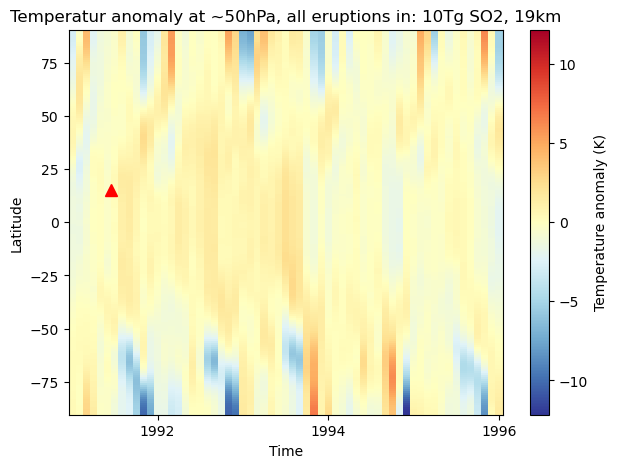

In [21]:
plot_temp_anomaly_lat_time(ds_19, base_clim = base, title="Temperatur anomaly at ~50hPa, all eruptions in: 10Tg SO2, 19km")

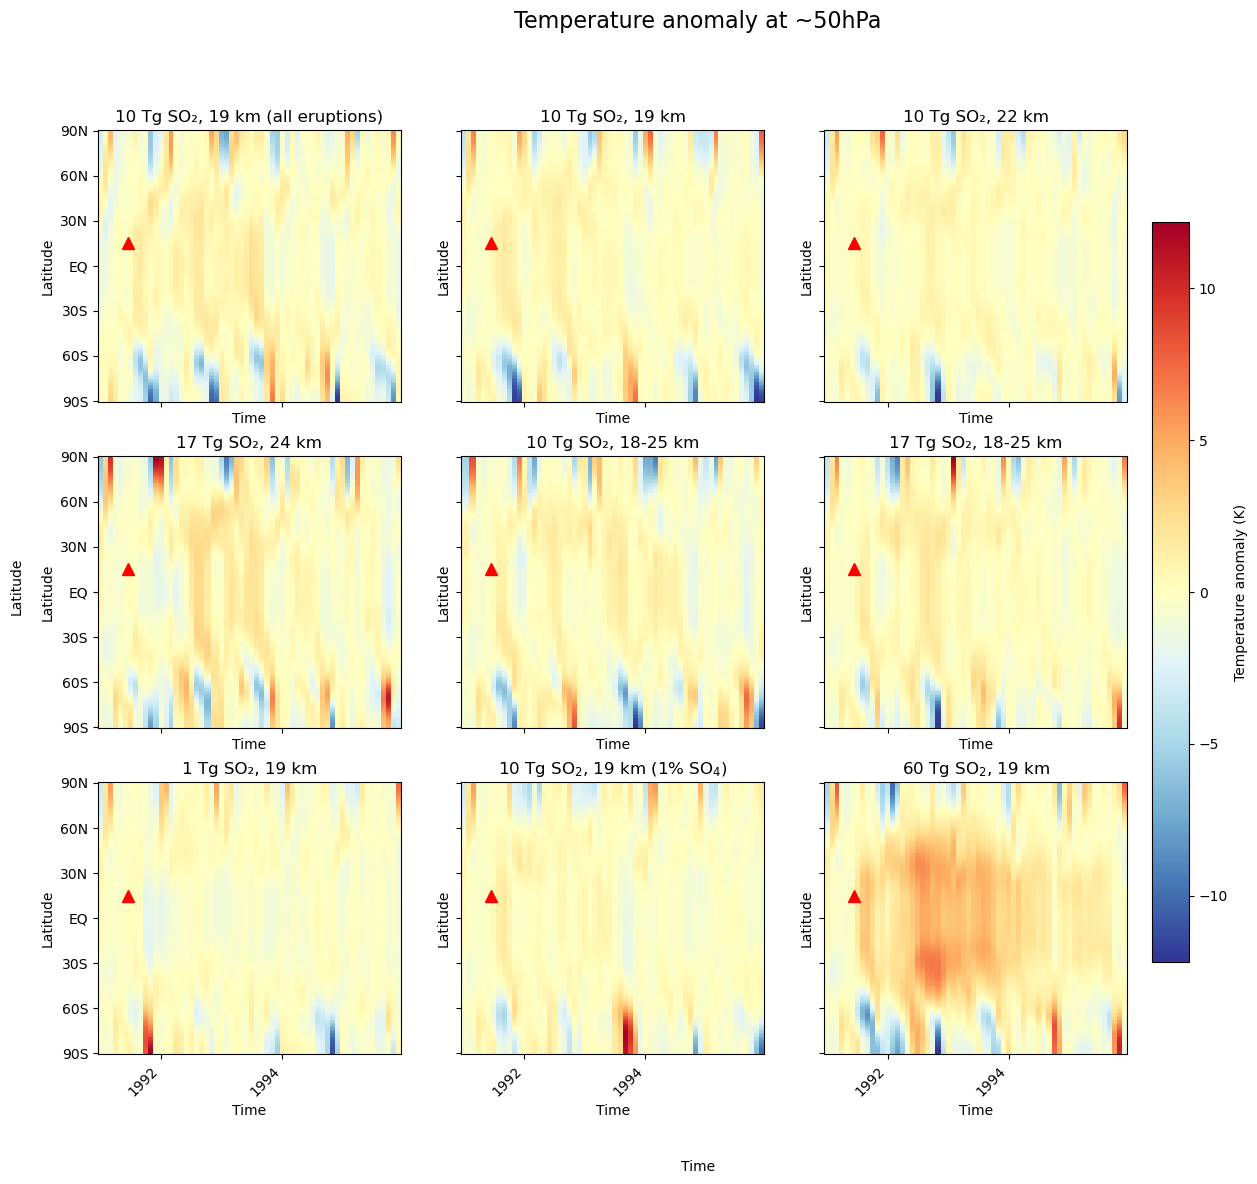

In [22]:
fig, axs = plt.subplots(3, 3, figsize=(16, 12), sharex=True, sharey=True)

datasets = [ds_19, ds_19_c, ds_22, ds_24, ds_1825, ds_1825_17tg, ds_1tg, ds_1pr, ds_60tg]
titles = [
    "10 Tg SO₂, 19 km (all eruptions)",
    "10 Tg SO₂, 19 km",
    "10 Tg SO₂, 22 km",
    "17 Tg SO₂, 24 km",
    "10 Tg SO₂, 18-25 km",
    "17 Tg SO₂, 18-25 km",
    "1 Tg SO₂, 19 km", 
    "10 Tg SO$_2$, 19 km (1% SO$_4$)",
    "60 Tg SO$_2$, 19 km"
]

for ax, ds, title in zip(axs.flat, datasets, titles):
    plot_temp_anomaly_lat_time(
        ds,
        base,
        lev=50,
        ax=ax,
        add_colorbar=False,
        title=title,
    )

axs[0, 0].set_yticks([-90, -60, -30, 0, 30, 60, 90])
axs[0, 0].set_yticklabels(["90S", "60S", "30S", "EQ", "30N", "60N", "90N"])

fig.colorbar(
    axs.flat[0].collections[0],
    ax=axs,
    label="Temperature anomaly (K)",
    shrink=0.8,
    pad=0.02,
)

for ax in axs[2, :]:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

fig.supxlabel('Time', fontsize=10)
fig.supylabel('Latitude', fontsize=10, x=0.07)
fig.suptitle("Temperature anomaly at ~50hPa", fontsize=16)
plt.show()

In [23]:
t_19 = ds_19["TREFHT"].sel(time=slice("1991-01", "1996-01"))
t_19_c = ds_19_c["TREFHT"]
t_22 = ds_22["TREFHT"]
t_24 = ds_24["TREFHT"]
t_1825 = ds_1825["TREFHT"]
t_1825_17tg = ds_1825_17tg["TREFHT"]
t_1tg = ds_1tg["TREFHT"]
t_1pr= ds_1pr["TREFHT"]
t_60tg = ds_60tg["TREFHT"]

In [24]:
def global_mean(da):
    lat = da["lat"]
    weights = np.cos(np.deg2rad(lat))
    return da.weighted(weights).mean(dim=("lat", "lon"))

ts_19 = global_mean(t_19) - 273.15
ts_19_c = global_mean(t_19_c) - 273.15
ts_22 = global_mean(t_22) - 273.15
ts_24 = global_mean(t_24) - 273.15
ts_1825 = global_mean(t_1825) - 273.15
ts_1825_17tg = global_mean(t_1825_17tg) - 273.15
ts_1tg = global_mean(t_1tg) - 273.15
ts_1pr = global_mean(t_1pr) - 273.15
ts_60tg = global_mean(t_60tg) - 273.15

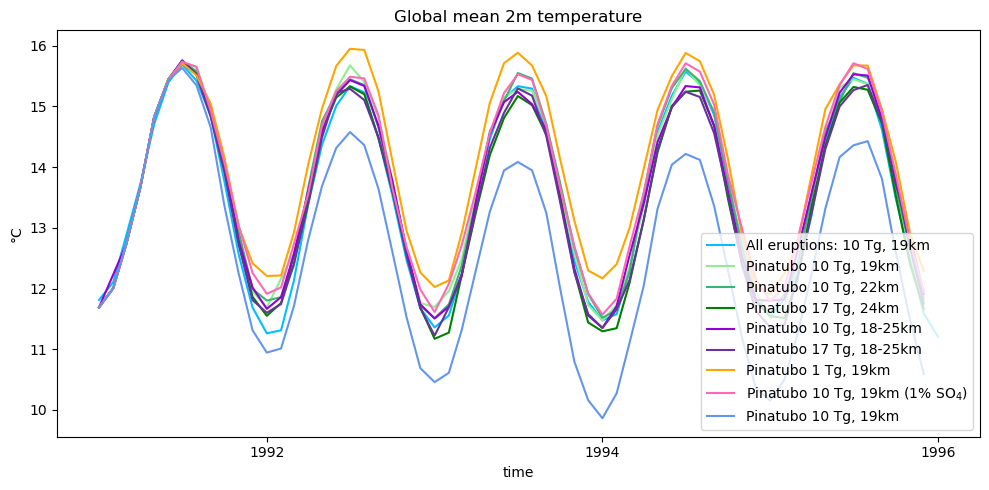

In [25]:
plt.figure(figsize=(10,5))

plt.plot(ts_19["time"], ts_19, color = "deepskyblue", label="All eruptions: 10 Tg, 19km")
plt.plot(ts_19_c["time"], ts_19_c, color = "lightgreen", label="Pinatubo 10 Tg, 19km")
plt.plot(ts_22["time"], ts_22, color = "mediumseagreen", label="Pinatubo 10 Tg, 22km")
plt.plot(ts_24["time"], ts_24, color = "green", label="Pinatubo 17 Tg, 24km")
plt.plot(ts_1825["time"], ts_1825, color="darkviolet", label="Pinatubo 10 Tg, 18-25km")
plt.plot(ts_1825_17tg["time"], ts_1825_17tg, color="rebeccapurple", label="Pinatubo 17 Tg, 18-25km")
plt.plot(ts_1tg["time"], ts_1tg, color="orange", label="Pinatubo 1 Tg, 19km")
plt.plot(ts_1pr["time"], ts_1pr, color="hotpink", label="Pinatubo 10 Tg, 19km (1% SO$_4$)")
plt.plot(ts_60tg["time"], ts_60tg, color="cornflowerblue", label="Pinatubo 10 Tg, 19km")


plt.xlabel("time")
plt.ylabel("°C")
plt.legend()
plt.title("Global mean 2m temperature")
plt.tight_layout()
plt.show()

In [26]:
temp_ctrl = ds_19["TREFHT"]-273.15
baseline = temp_ctrl.sel(time=slice("1976-01", "1990-12"))
base = global_mean(baseline)
base = base.groupby("time.month").mean("time")

In [27]:
def anomalies(da, base_monthly):
    return da.groupby("time.month") - base_monthly

In [28]:
a_19_c = anomalies(ts_19_c, base)
a_22 = anomalies(ts_22, base)
a_24 = anomalies(ts_24, base)
a_1825 = anomalies(ts_1825, base)
a_1825_17tg = anomalies(ts_1825_17tg, base)
a_1tg = anomalies(ts_1tg, base)
a_1pr = anomalies(ts_1pr, base)
a_60tg = anomalies(ts_60tg, base)

"""a_19_c = global_mean(a_19_c)
a_22 = global_mean(a_22)
a_24 = global_mean(a_24)
a_1825 = global_mean(a_1825)
a_1825_17tg = global_mean(a_1825_17tg)
a_1tg = global_mean(a_1tg)
a_1pr = global_mean(a_1pr)
a_60tg = global_mean(a_60tg)"""

'a_19_c = global_mean(a_19_c)\na_22 = global_mean(a_22)\na_24 = global_mean(a_24)\na_1825 = global_mean(a_1825)\na_1825_17tg = global_mean(a_1825_17tg)\na_1tg = global_mean(a_1tg)\na_1pr = global_mean(a_1pr)\na_60tg = global_mean(a_60tg)'

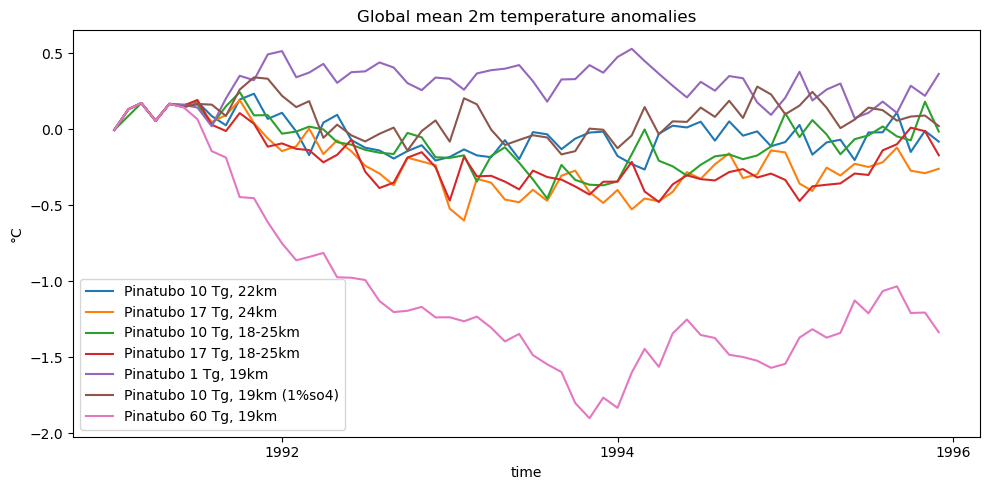

In [29]:
plt.figure(figsize=(10,5))

#plt.plot(a_19["time"], a_19, label="Pinatubo 10 Tg, 19km")
plt.plot(a_22["time"], a_22, label="Pinatubo 10 Tg, 22km")
plt.plot(a_24["time"], a_24, label="Pinatubo 17 Tg, 24km")
plt.plot(a_1825["time"], a_1825, label="Pinatubo 10 Tg, 18-25km")
plt.plot(a_1825_17tg["time"], a_1825_17tg, label="Pinatubo 17 Tg, 18-25km")
plt.plot(a_1tg["time"], a_1tg, label="Pinatubo 1 Tg, 19km")
plt.plot(a_1pr["time"], a_1pr, label="Pinatubo 10 Tg, 19km (1%so4)")
plt.plot(a_60tg["time"], a_60tg, label="Pinatubo 60 Tg, 19km")

plt.xlabel("time")
plt.ylabel("°C")
plt.legend()
plt.title("Global mean 2m temperature anomalies")
plt.tight_layout()
plt.show()

In [30]:
def tropical_mean(ds, lat_bound=20):
    trop_ds = ds.sel(lat=slice(-lat_bound, lat_bound))
    
    weights = np.cos(np.deg2rad(trop_ds.lat))
    weights.name = "weights"
    
    return trop_ds.weighted(weights).mean(dim=["lat", "lon"])

temp_ctrl = ds_19["TREFHT"]-273.15
baseline = temp_ctrl.sel(time=slice("1976-01", "1990-12"))
base_trop = tropical_mean(baseline) 
base_trop = base_trop.groupby("time.month").mean("time")

In [31]:
t_19_c = tropical_mean(t_19_c) - 273.15
t_22 = tropical_mean(t_22) - 273.15
t_24 = tropical_mean(t_24) - 273.15
t_1825 = tropical_mean(t_1825) - 273.15
t_1825_17tg  = tropical_mean(t_1825_17tg) - 273.15
t_1tg = tropical_mean(t_1tg) - 273.15 
t_1pr = tropical_mean(t_1pr) - 273.15
t_60tg = tropical_mean(t_60tg) - 273.15

at_19_c = anomalies(t_19_c, base_trop)
at_22 = anomalies(t_22, base_trop)
at_24 = anomalies(t_24, base_trop)
at_1825 = anomalies(t_1825, base_trop)
at_1825_17tg = anomalies(t_1825_17tg, base_trop)
at_1tg = anomalies(t_1tg, base_trop)
at_1pr = anomalies(t_1pr, base_trop)
at_60tg = anomalies(t_60tg, base_trop)

<>:18: SyntaxWarning: invalid escape sequence '\c'
<>:18: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_797803/2206925853.py:18: SyntaxWarning: invalid escape sequence '\c'
  ax[0].set_ylabel("[$^\circ$C]")


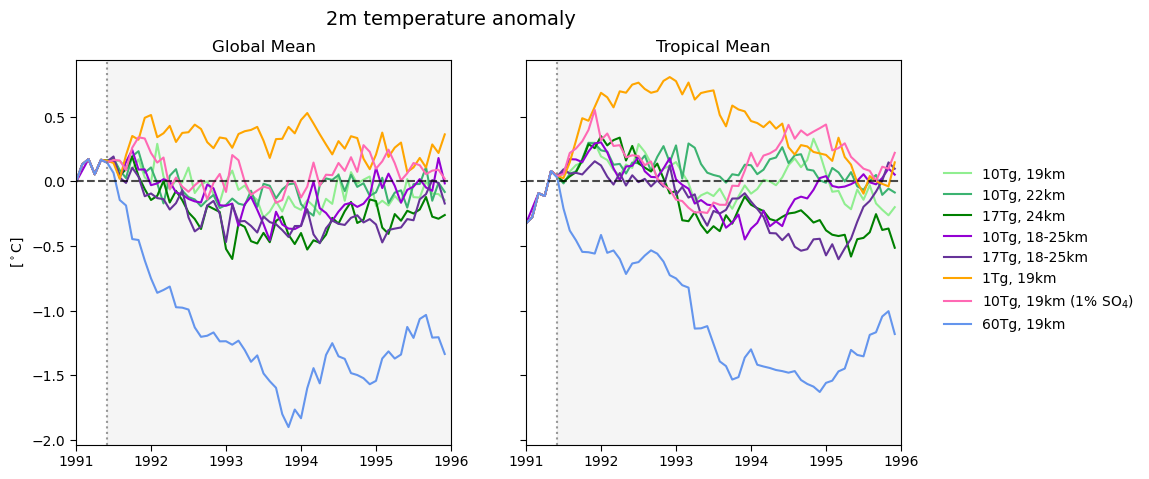

In [32]:
def to_float(x):
    if isinstance(x.time.values[0], np.datetime64):
        times = pd.DatetimeIndex(x.time.values)
        return [t.year + (t.month-1)/12 for t in times]
    else:
        return [t.year + (t.month-1)/12 for t in x.time.values]
    
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax[0].plot(to_float(a_19_c), a_19_c, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(a_22),a_22, color="mediumseagreen", label="10Tg, 22km")
ax[0].plot(to_float(a_24), a_24, color="green", label="17Tg, 24km") 
ax[0].plot(to_float(a_1825),a_1825, color="darkviolet", label="10Tg, 18-25km")
ax[0].plot(to_float(a_1825_17tg), a_1825_17tg, color="rebeccapurple", label="17Tg, 18-25km")
ax[0].plot(to_float(a_1tg), a_1tg, color="orange", label="1Tg, 19km")
ax[0].plot(to_float(a_1pr), a_1pr, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[0].plot(to_float(a_60tg), a_60tg, color="cornflowerblue", label="60Tg, 19km")
ax[0].set_ylabel("[$^\circ$C]")
ax[0].set_title("Global Mean", fontsize=12)

ax[1].plot(to_float(at_19_c), at_19_c, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(at_22), at_22, color="mediumseagreen", label="10Tg, 22km")
ax[1].plot(to_float(at_24), at_24, color="green", label="17Tg, 24km") 
ax[1].plot(to_float(at_1825), at_1825, color="darkviolet", label="10Tg, 18-25km")
ax[1].plot(to_float(at_1825_17tg), at_1825_17tg, color="rebeccapurple", label="17Tg, 18-25km")
ax[1].plot(to_float(at_1tg), at_1tg, color="orange", label="1Tg, 19km")
ax[1].plot(to_float(at_1pr), at_1pr, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
ax[1].plot(to_float(at_60tg), at_60tg, color="cornflowerblue", label="60Tg, 19km")
ax[1].set_title("Tropical Mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    a.axhline(0, color="black", ls="--", alpha=0.7)
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("2m temperature anomaly", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

In [33]:
oh_19 = ds_19["OH"].weighted(weighted_lat).mean(dim=["lev", "lat", "lon"])
oh_19_pin = oh_19.sel(time=slice("1991-01", "1996-01"))
oh_19_c = ds_19_c["OH"].weighted(weighted_lat_19_c).mean(dim=["lev", "lat", "lon"])
oh_22 = ds_22["OH"].weighted(weighted_lat_22).mean(dim=["lev", "lat", "lon"])
oh_24 = ds_24["OH"].weighted(weighted_lat_24).mean(dim=["lev", "lat", "lon"])
oh_1825 = ds_1825["OH"].weighted(weighted_lat_1825).mean(dim=["lev", "lat", "lon"])
oh_1825_17tg = ds_1825_17tg["OH"].weighted(weighted_lat_1825_17tg).mean(dim=["lev", "lat", "lon"])
oh_1tg = ds_1tg["OH"].weighted(weighted_lat_1tg).mean(dim=["lev", "lat", "lon"])
oh_1pr = ds_1pr["OH"].weighted(weighted_lat_1pr).mean(dim=["lev", "lat", "lon"])
oh_60tg = ds_60tg["OH"].weighted(weighted_lat_60tg).mean(dim=["lev", "lat", "lon"])


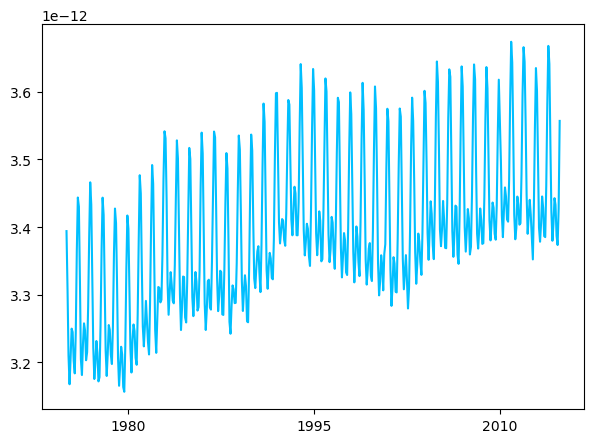

: 

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(oh_19.time, oh_19, color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(oh_19_pin.time, oh_19_pin, color = "deepskyblue", label = "All eruptions in: 10Tg SO2, 19km")
plt.plot(oh_19_c.time, oh_19_c, color = "lightgreen", label = "Pinatubo only: 10Tg SO2, 19km")
plt.plot(oh_22.time, oh_22, color = "mediumseagreen", label = "Pinatubo only: 10Tg SO2, 22km")
plt.plot(oh_24.time, oh_24, color = "green", label = "Pinatubo only: 17Tg SO2, 24km")
plt.plot(oh_1825.time, oh_1825, color="darkviolet", label = "Pinatubo only: 10Tg SO2, 18-25km")
plt.plot(oh_1825_17tg.time, oh_1825_17tg, color="rebeccapurple", label = "Pinatubo only: 17Tg SO2, 18-25km")
plt.plot(oh_1tg.time, oh_1tg, color="orange", label = "Pinatubo only: 1Tg SO2, 19km")
plt.plot(oh_1pr.time, oh_1pr, color="hotpink", label = "Pinatubo only: 10Tg SO2, with 1% as SO4, 19km")
plt.plot(oh_60tg.time, oh_60tg, color="cornflowerblue", label = "Pinatubo only: 60Tg SO2, 19km")

plt.xlabel("Year")
plt.title("OH (global mean)")
fig = plt.gcf()
ax = plt.gca()

fig.subplots_adjust(right=0.65)

ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.show()

In [ ]:
tropopause = ds_19["TROP_P"].weighted(weighted_lat).mean(dim=["lat", "lon"])
tropopause_22 = ds_22["TROP_P"].weighted(weighted_lat_22).mean(dim=["lat", "lon"])
tropopause_19_c = ds_19_c["TROP_P"].weighted(weighted_lat_19_c).mean(dim=["lat", "lon"])
tropopause_24 = ds_24["TROP_P"].weighted(weighted_lat_24).mean(dim=["lat", "lon"])
tropopause_1825 = ds_1825["TROP_P"].weighted(weighted_lat_1825).mean(dim=["lat", "lon"])
tropopause_1825_17tg = ds_1825_17tg["TROP_P"].weighted(weighted_lat_1825_17tg).mean(dim=["lat", "lon"])
tropopause_1tg = ds_1tg["TROP_P"].weighted(weighted_lat_1tg).mean(dim=["lat", "lon"])
tropopause_1pr= ds_1pr["TROP_P"].weighted(weighted_lat_1pr).mean(dim=["lat", "lon"])
tropopause_60tg= ds_60tg["TROP_P"].weighted(weighted_lat_60tg).mean(dim=["lat", "lon"])

p_lev = tropopause * 0.01
p_lev_22 = tropopause_22 * 0.01
p_lev_19_c = tropopause_19_c * 0.01
p_lev_24 = tropopause_24 * 0.01
p_lev_1825 = tropopause_1825 * 0.01
p_lev_1825_17tg = tropopause_1825_17tg * 0.01
p_lev_1tg = tropopause_1tg * 0.01
p_lev_1pr = tropopause_1pr * 0.01
p_lev_60tg = tropopause_60tg * 0.01

In [ ]:
def get_weighted_oh(ds, p_lev, lat_min=-90, lat_max=90):
    ds_area = ds.sel(lat=slice(lat_min, lat_max))
    
    weights_lat = np.cos(np.deg2rad(ds_area.lat))
    
    lev_vals = ds_area.lev.values
    lev_diff = np.abs(np.gradient(lev_vals))
    wl = xr.DataArray(lev_diff, coords={'lev': ds_area.lev}, dims=['lev'])
    
    oh = ds_area["OH"].where(ds_area["lev"] <= p_lev)
    oh_h = oh.weighted(weights_lat).mean(dim=["lat", "lon"])
    oh_final = oh_h.weighted(wl).mean(dim="lev")
    
    return oh_final

In [ ]:
base = get_weighted_oh(ds_19, p_lev).sel(time=slice("1985-01", "1990-01"))
base = base.groupby("time.month").mean(dim="time")

In [ ]:
oh_19 = get_weighted_oh(ds_19, p_lev).sel(time=slice("1991-01", "1996-01")).groupby("time.month") - base
oh_19_c = get_weighted_oh(ds_19_c, p_lev_19_c).groupby("time.month") - base
oh_22 = get_weighted_oh(ds_22, p_lev_22).groupby("time.month") - base
oh_24 = get_weighted_oh(ds_24, p_lev_24).groupby("time.month") - base
oh_1825 = get_weighted_oh(ds_1825, p_lev_1825).groupby("time.month") - base
oh_1825_17tg    = get_weighted_oh(ds_1825_17tg, p_lev_1825_17tg).groupby("time.month") - base
oh_1tg = get_weighted_oh(ds_1tg, p_lev_1tg).groupby("time.month") - base
oh_1pr = get_weighted_oh(ds_1pr, p_lev_1pr).groupby("time.month") - base
oh_60tg = get_weighted_oh(ds_60tg, p_lev_60tg).groupby("time.month") - base

In [ ]:
base_trop = get_weighted_oh(ds_19, p_lev, lat_min=-20, lat_max=20).sel(time=slice("1985-01", "1990-01"))
base_trop = base_trop.groupby("time.month").mean(dim="time")

In [ ]:
oh_19_trop = get_weighted_oh(ds_19, p_lev, lat_min=-20, lat_max=20).sel(time=slice("1991-01", "1996-01")).groupby("time.month") - base_trop
oh_19_c_trop = get_weighted_oh(ds_19_c, p_lev_19_c, lat_min=-20, lat_max=20).groupby("time.month")- base_trop
oh_22_trop = get_weighted_oh(ds_22, p_lev_22, lat_min=-20, lat_max=20).groupby("time.month")- base_trop
oh_24_trop = get_weighted_oh(ds_24, p_lev_24, lat_min=-20, lat_max=20).groupby("time.month")- base_trop
oh_1825_trop = get_weighted_oh(ds_1825, p_lev_1825, lat_min=-20, lat_max=20).groupby("time.month")- base_trop
oh_1825_17tg_trop = get_weighted_oh(ds_1825_17tg, p_lev_1825_17tg, lat_min=-20, lat_max=20).groupby("time.month")- base_trop
oh_1tg_trop = get_weighted_oh(ds_1tg, p_lev_1tg, lat_min=-20, lat_max=20).groupby("time.month")- base_trop
oh_1pr_trop = get_weighted_oh(ds_1pr, p_lev_1pr, lat_min=-20, lat_max=20).groupby("time.month")- base_trop
oh_60tg_trop = get_weighted_oh(ds_60tg, p_lev_60tg, lat_min=-20, lat_max=20).groupby("time.month")- base_trop

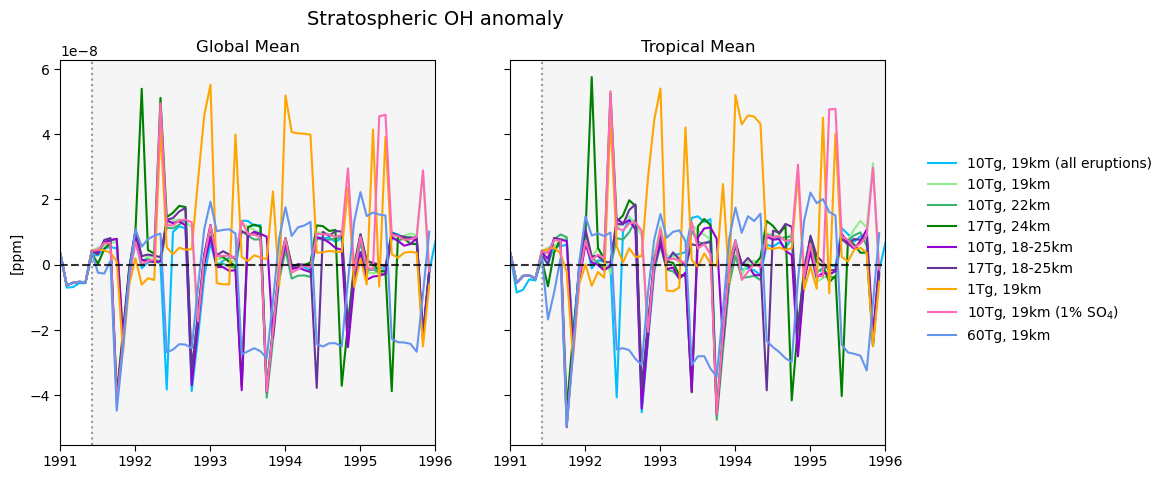

In [ ]:
def to_float(x):
    if isinstance(x.time.values[0], np.datetime64):
        times = pd.DatetimeIndex(x.time.values)
        return [t.year + (t.month-1)/12 for t in times]
    else:
        return [t.year + (t.month-1)/12 for t in x.time.values]
    
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax[0].plot(to_float(oh_19), oh_19 * 100000, color="deepskyblue", label="10Tg, 19km (all eruptions)")
ax[0].plot(to_float(oh_19_c), oh_19_c * 100000, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(oh_22),oh_22 * 100000, color="mediumseagreen", label="10Tg, 22km")
ax[0].plot(to_float(oh_24), oh_24 * 100000, color="green", label="17Tg, 24km") 
ax[0].plot(to_float(oh_1825),oh_1825 * 100000, color="darkviolet", label="10Tg, 18-25km")
ax[0].plot(to_float(oh_1825_17tg), oh_1825_17tg * 100000, color="rebeccapurple", label="17Tg, 18-25km")
#ax[0].plot(to_float(oh_1tg), oh_1tg * 100000, color="orange", label="1Tg, 19km")
ax[0].plot(to_float(oh_1pr), oh_1pr * 100000, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
#ax[0].plot(to_float(oh_60tg), oh_60tg * 100000, color="cornflowerblue", label="60Tg, 19km")
ax[0].set_ylabel("[ppm]")
ax[0].set_title("Global Mean", fontsize=12)

ax[1].plot(to_float(oh_19_trop), oh_19_trop * 100000, color="deepskyblue", label="10Tg, 19km (all eruptions)")
ax[1].plot(to_float(oh_19_c_trop), oh_19_c_trop * 100000, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(oh_22_trop), oh_22_trop * 100000, color="mediumseagreen", label="10Tg, 22km")
ax[1].plot(to_float(oh_24_trop), oh_24_trop * 100000, color="green", label="17Tg, 24km") 
ax[1].plot(to_float(oh_1825_trop), oh_1825_trop * 100000, color="darkviolet", label="10Tg, 18-25km")
ax[1].plot(to_float(oh_1825_17tg_trop), oh_1825_17tg_trop * 100000, color="rebeccapurple", label="17Tg, 18-25km")
#ax[1].plot(to_float(oh_1tg_trop), oh_1tg_trop * 100000, color="orange", label="1Tg, 19km")
ax[1].plot(to_float(oh_1pr_trop), oh_1pr_trop * 100000, color="hotpink", label="10Tg, 19km (1% SO$_4$)")
#ax[1].plot(to_float(oh_60tg_trop), oh_60tg_trop * 100000, color="cornflowerblue", label="60Tg, 19km")
ax[1].set_title("Tropical Mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    a.axhline(0, color="black", ls="--", alpha=0.8)
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric OH anomaly", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

ax[0].plot(to_float(oh_19_c), oh_19_c * 100000, color="lightgreen", label="10Tg, 19km")
ax[0].plot(to_float(oh_1tg), oh_1tg * 100000, color="orange", label="1Tg, 19km")
ax[0].plot(to_float(oh_60tg), oh_60tg * 100000, color="cornflowerblue", label="60Tg, 19km")
ax[0].set_ylabel("[ppm]")
ax[0].set_title("Global Mean", fontsize=12)

ax[1].plot(to_float(oh_19_c_trop), oh_19_c_trop * 100000, color="lightgreen", label="10Tg, 19km")
ax[1].plot(to_float(oh_1tg_trop), oh_1tg_trop * 100000, color="orange", label="1Tg, 19km")
ax[1].plot(to_float(oh_60tg_trop), oh_60tg_trop * 100000, color="cornflowerblue", label="60Tg, 19km")
ax[1].set_title("Tropical Mean", fontsize=12)

eruption_float = 1991 + (6-1)/12  
end_float = 1996 + (1-1)/12   

for i, a in enumerate(ax):
    a.axvline(eruption_float, color='gray', ls=":", alpha=0.8)
    a.axvspan(eruption_float, end_float, color='gray', alpha=0.08, zorder=0)
    a.axhline(0, color="black", ls="--", alpha=0.8)
    a.tick_params(direction='out', length=4)

    a.set_xticks([1991, 1992, 1993, 1994, 1995, 1996])
    a.set_xticklabels(["1991", "1992", "1993", "1994", "1995", "1996"])
    
    a.set_xlim(1991, 1996)


handles, labels = ax[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False
)

fig.suptitle("Stratospheric OH anomaly", fontsize=14)
fig.subplots_adjust(right=0.95)
plt.show()